## **Feature Engineering : Calibration/Holdout RFM & CLV Target**

This notebook builds the modeling-ready dataset for CLV prediction. Unlike the RFM table built in `2_eda.ipynb` (which summarized each customer's entire history), this notebook splits the timeline into a **calibration period** (used to compute RFM features) and a **holdout period** (used to compute the actual future spend we're trying to predict). This produces a genuine forward-looking prediction target rather than a description of the past.

**Split:** 18-month calibration (2009-12-01 to 2011-06-09) / 6-month holdout (2011-06-10 to 2011-12-09), chosen to give stable RFM features while ensuring the holdout period captures a full seasonal peak (Oct–Nov).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")
from utils import report_reduction
from config import CLEAN_DATA_PATH
from features import compute_rfm
from config import MODELING_DATA_PATH
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the fully cleaned transaction-level dataset
df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=["InvoiceDate"])

# Recreate the Revenue column (not saved in the cleaned CSV, since it was added during EDA)
df['Revenue'] = df['Quantity'] * df['Price']

df.shape

(776641, 9)

### Define the Calibration/Holdout Split

We split transactions at the cutoff date **2011-06-09** (end of an 18-month calibration window). Transactions on or before this date form the calibration period, used to compute RFM features. Transactions after this date form the holdout period, used to compute each customer's actual future spend which is our CLV prediction target.

In [2]:
cutoff_date = pd.Timestamp("2011-06-09")

calibration = df[df['InvoiceDate'] <= cutoff_date].copy()
holdout = df[df['InvoiceDate'] > cutoff_date].copy()

print("Calibration period:", calibration['InvoiceDate'].min(), "to", calibration['InvoiceDate'].max())
print("Calibration rows:", calibration.shape)
print()
print("Holdout period:", holdout['InvoiceDate'].min(), "to", holdout['InvoiceDate'].max())
print("Holdout rows:", holdout.shape)

Calibration period: 2009-12-01 07:45:00 to 2011-06-08 17:09:00
Calibration rows: (536408, 9)

Holdout period: 2011-06-09 07:53:00 to 2011-12-09 12:50:00
Holdout rows: (240233, 9)


The calibration period spans 2009-12-01 to 2011-06-08 (536,408 rows), and the holdout period spans 2011-06-09 to 2011-12-09 (240,233 rows). The holdout period accounts for a disproportionately large share of transactions (~31%) relative to its shorter timespan (~25% of the total date range), consistent with it capturing the October–November seasonal peak identified during EDA.

### Identify Cold-Start Customers

Customers with no transactions in the calibration period have no RFM features to predict from, they only acquired during the holdout window. These "cold-start" customers represent a different problem (predicting value for brand-new customers with no history) and are excluded from this modeling exercise.

In [3]:
calibration_customers = set(calibration['Customer ID'].unique())
holdout_customers = set(holdout['Customer ID'].unique())

cold_start_customers = holdout_customers - calibration_customers

print("Customers in calibration period:", len(calibration_customers))
print("Customers in holdout period:", len(holdout_customers))
print("Cold-start customers (holdout only, no calibration history):", len(cold_start_customers))

Customers in calibration period: 4951
Customers in holdout period: 3487
Cold-start customers (holdout only, no calibration history): 910


Of the 4,951 customers with calibration-period history, 910 additional customers appear only in the holdout period (cold-start, excluded from this exercise). The remaining calibration customers may or may not have purchased again during holdout, those who didn't are of particular interest later for churn classification.

In [4]:
# Calibration customers who made at least one purchase during holdout (repeat buyers)
returning_customers = calibration_customers & holdout_customers

# Calibration customers with NO purchases during holdout (went quiet / churned within this window)
inactive_after_calibration = calibration_customers - holdout_customers

print("Calibration customers who returned during holdout:", len(returning_customers))
print("Calibration customers with no holdout purchases:", len(inactive_after_calibration))

Calibration customers who returned during holdout: 2577
Calibration customers with no holdout purchases: 2374


Of the 4,951 calibration-period customers, 2,577 (52%) returned to make at least one purchase during the holdout period, while 2,374 (48%) made no purchases at all during holdout. This near-even split is a useful early signal: for the regression task, roughly half of our CLV target values will be exactly zero (no future spend), which is worth accounting for when selecting and evaluating regression models later. It's also directly relevant to the later churn classification task, where "no holdout purchases" is a natural basis for defining a churn label.

### Compute RFM Features on the Calibration Period

We compute Recency, Frequency, and Monetary features using only the calibration period, so these features reflect what was knowable about each customer as of the cutoff date i.e., without any information leakage from the holdout period.

In [5]:
# Reference date for Recency: one day after the calibration period's cutoff date
calibration_reference_date = cutoff_date + pd.Timedelta(days=1)

rfm_calibration = compute_rfm(
    calibration,
    reference_date=calibration_reference_date
)

rfm_calibration.shape

(4951, 3)

### Compute the CLV Target (Actual Holdout-Period Spend)

For each calibration customer, we compute their actual total spend during the holdout period. This is the value we're trying to predict 
i.e., genuine future revenue, not a summary of the past. Customers with no holdout purchases (48% of the calibration base, per the earlier check) will correctly receive a target value of 0.

In [6]:
# Total revenue per customer during the holdout period
holdout_revenue = holdout.groupby('Customer ID')['Revenue'].sum()

# Reindex to all calibration customers, filling missing (no holdout purchase) with 0
clv_target = holdout_revenue.reindex(calibration_customers, fill_value=0)
clv_target.name = 'CLV_Target'

clv_target.shape

(4951,)

### Merge RFM Features and CLV Target into the Final Modeling Table

We combine the calibration-period RFM features with the holdout-period CLV target into a single table, indexed by Customer ID. This is the dataset the regression model will be trained on.

In [7]:
modeling_df = rfm_calibration.join(clv_target)

modeling_df.shape

(4951, 4)

### Sanity Check the Modeling Table

We confirm the merge was clean (no missing values), that the zero-target count matches our earlier calculation (2,374 customers with no holdout purchases), and review summary statistics for all four columns.

In [8]:
# Check for missing values
print("Missing values per column:")
print(modeling_df.isnull().sum())

# Confirm the zero-target count matches our earlier calculation (2,374)
zero_target_count = (modeling_df['CLV_Target'] == 0).sum()
print(f"\nCustomers with CLV_Target = 0: {zero_target_count}")

# Summary statistics
modeling_df.describe()

Missing values per column:
Recency       0
Frequency     0
Monetary      0
CLV_Target    0
dtype: int64

Customers with CLV_Target = 0: 2374


,Recency,Frequency,Monetary,CLV_Target
count,4951.000000,4951.000000,4951.000000,4951.000000
mean,171.854979,5.250656,2376.361435,920.737580
std,145.048960,10.026550,10588.395004,5616.729574
min,1.000000,1.000000,2.900000,0.000000
25%,39.000000,1.000000,310.785000,0.000000
50%,148.000000,3.000000,741.540000,93.780000
75%,249.000000,6.000000,1935.725000,678.225000
max,555.000000,240.000000,396971.370000,184015.670000


- The modeling table contains no missing values across all four columns.
- The zero-target count (2,374) matches our earlier calculation exactly, confirming the merge and target construction were correct.
- The `CLV_Target` distribution shows the expected pattern: roughly half of customers have zero future spend.
- A small number of high-value customers drive very large values (up to £184,015.67), consistent with the revenue concentration identified throughout the EDA phase.
- This heavy-tailed, zero-inflated distribution will be an important consideration when selecting and evaluating regression models in the next phase.

### Additional Features

Beyond core RFM, we add four more features computed from the calibration period, which may improve model performance and provide additional business-interpretable signals:

- **Average Order Value (AOV)** = Monetary / Frequency —> distinguishes "many small orders" from "few large orders"
- **Tenure** = days since each customer's first purchase (relative to the calibration reference date) —> captures how long a customer has been active
- **Unique Products Purchased** = count of distinct `StockCode` values —> a product-variety signal
- **Average Days Between Purchases** = Tenure / Frequency —> a purchase-rhythm signal distinct from Recency alone

In [9]:
# Average Order Value: revenue per order
aov = rfm_calibration['Monetary'] / rfm_calibration['Frequency']

# Tenure: days since first purchase, relative to the calibration reference date
first_purchase = calibration.groupby('Customer ID')['InvoiceDate'].min()
tenure = (calibration_reference_date - first_purchase).dt.days

# Unique products purchased
unique_products = calibration.groupby('Customer ID')['StockCode'].nunique()

# Average days between purchases (purchase rhythm)
# Guard against division by zero for single-order customers (Frequency = 1)
avg_days_between_purchases = tenure / rfm_calibration['Frequency'].replace(0, np.nan)

In [10]:
# Add all four to the modeling table
modeling_df['AOV'] = aov
modeling_df['Tenure'] = tenure
modeling_df['Unique_Products'] = unique_products
modeling_df['Avg_Days_Between_Purchases'] = avg_days_between_purchases

modeling_df.shape

(4951, 8)

### Check for Missing Values in the New Features

`Avg_Days_Between_Purchases` is undefined for customers with only a single order (no interval to measure). We check how many customers this affects before deciding how to handle it.

In [11]:
modeling_df.isnull().sum()

Recency                       0
Frequency                     0
Monetary                      0
CLV_Target                    0
AOV                           0
Tenure                        0
Unique_Products               0
Avg_Days_Between_Purchases    0
dtype: int64

No missing values were introduced by the new features. `Avg_Days_Between_Purchases` is well-defined even for single-order customers (Tenure / 1 = Tenure), since every customer has at least one order by construction i.e., there is no genuine divide-by-zero case here. For a single-order customer, this feature effectively equals their Tenure, which is a reasonable interpretation: their "average interval between purchases" is bounded by how long they've been a customer with only one purchase in that time.

In [12]:
modeling_df.describe()

,Recency,Frequency,Monetary,CLV_Target,AOV,Tenure,Unique_Products,Avg_Days_Between_Purchases
count,4951.000000,4951.000000,4951.000000,4951.000000,4951.000000,4951.000000,4951.000000,4951.000000
mean,171.854979,5.250656,2376.361435,920.737580,367.150950,363.601293,70.615633,151.513759
std,145.048960,10.026550,10588.395004,5616.729574,519.107532,156.939147,98.028169,128.035242
min,1.000000,1.000000,2.900000,0.000000,2.900000,1.000000,1.000000,1.000000
25%,39.000000,1.000000,310.785000,0.000000,174.845000,239.000000,17.000000,58.000000
50%,148.000000,3.000000,741.540000,93.780000,278.431667,400.000000,40.000000,109.250000
75%,249.000000,6.000000,1935.725000,678.225000,411.732500,499.000000,88.000000,211.000000
max,555.000000,240.000000,396971.370000,184015.670000,14844.766667,555.000000,2001.000000,555.000000


### Feature Correlation & Multicollinearity Check

Before finalizing the modeling table, we check for strong correlations between features. Some engineered features are mathematically derived from others (e.g., `AOV = Monetary / Frequency`), so we expect some inherent correlation and this check quantifies it and flags anything that may need addressing before modeling. \
*Note: true feature importance requires a trained model and is deferred to the Regression phase; this step covers only correlation-based redundancy, which can be assessed on the data alone.*

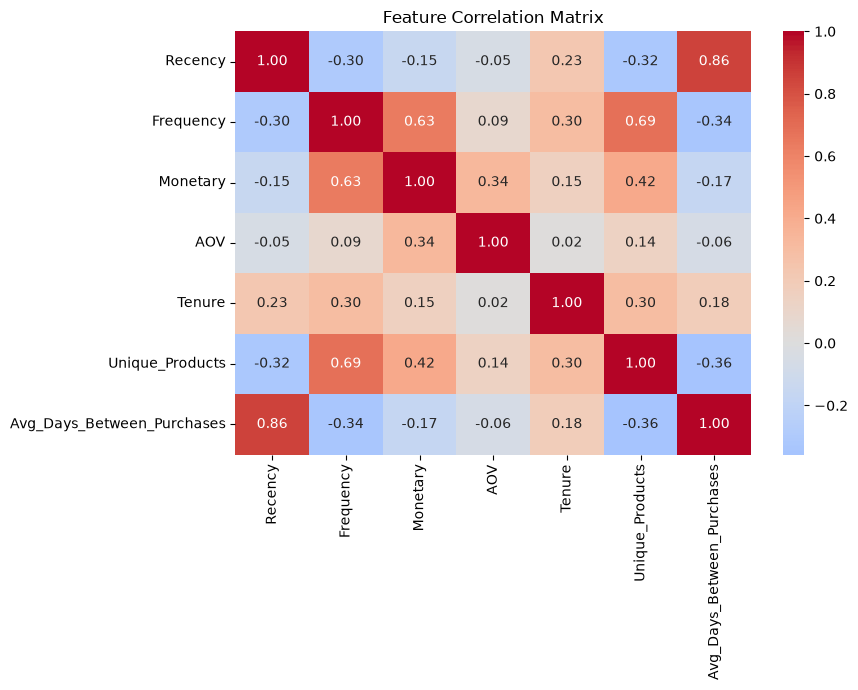

In [13]:
feature_cols = ['Recency', 'Frequency', 'Monetary', 'AOV', 'Tenure', 'Unique_Products', 'Avg_Days_Between_Purchases']
corr_matrix = modeling_df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
X = modeling_df[feature_cols]
vif_data = pd.DataFrame({
    'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(len(feature_cols))]
})
vif_data.sort_values('VIF', ascending=False)

,Feature,VIF
6,Avg_Days_Between_Purchases,3.901189
0,Recency,3.861593
1,Frequency,2.931766
5,Unique_Products,2.082712
2,Monetary,1.965291
4,Tenure,1.328940
3,AOV,1.184333


### Correlation & Multicollinearity Summary

- The correlation matrix shows a **strong pairwise relationship** between `Recency` and `Avg_Days_Between_Purchases` (0.86).
- **Moderate relationships** also appear between `Frequency`/`Unique_Products` (0.69) and `Frequency`/`Monetary` (0.63).
- These correlations are expected, since these features share underlying purchasing behavior.
- **VIF analysis, however, shows all features well below the concerning threshold** (VIF > 5) including the two most correlated features: `Avg_Days_Between_Purchases` (3.90) and `Recency` (3.86).
- This indicates that while pairwise correlations exist, there is **no severe multicollinearity** once all features are considered jointly.
- VIF measures how well a feature is predicted by the *combination* of all other features — a more rigorous test than pairwise correlation alone.
- **No features are dropped at this stage.**
- `Recency` and `Avg_Days_Between_Purchases` are conceptually related and worth noting when interpreting model coefficients later (particularly for linear models), but do not require removal based on this analysis.

### Data Leakage Check

Before finalizing the table, we explicitly verify that the calibration and holdout periods do not overlap in time, and that RFM features were computed strictly from calibration-period data. This confirms no information from the future (holdout period) leaked into the features used for prediction.

In [15]:
# Confirm calibration and holdout periods do not overlap
assert calibration['InvoiceDate'].max() <= cutoff_date, "Calibration period leaks past cutoff date"
assert holdout['InvoiceDate'].min() > cutoff_date, "Holdout period starts before cutoff date"

# Confirm every customer in the modeling table has calibration-period history
assert modeling_df.index.isin(calibration_customers).all(), "Modeling table contains customers with no calibration history"

print("All data leakage checks passed.")

All data leakage checks passed.


### Data Type Validation

We confirm all columns in the modeling table have appropriate numeric types before saving. We also investigate why `CLV_Target` appeared as `int64` in earlier summary statistics, since it is derived from `Revenue` (a float column), which is unexpected.

In [16]:
modeling_df.dtypes

Recency                         int64
Frequency                       int64
Monetary                      float64
CLV_Target                    float64
AOV                           float64
Tenure                          int64
Unique_Products                 int64
Avg_Days_Between_Purchases    float64
dtype: object

All columns have appropriate types: `Recency`, `Frequency`, `Tenure`, and `Unique_Products` are `int64` (naturally whole-number counts), while `Monetary`, `CLV_Target`, `AOV`, and `Avg_Days_Between_Purchases` are `float64` (money and averaged values). The earlier appearance of `CLV_Target` as `int64` was from the `.isnull().sum()` output, which always returns integer counts regardless of the underlying column type, not an actual dtype issue. No type conversions are needed; the table is fully numeric and ready for modeling.

### Visualize the CLV_Target Distribution

We visualize the CLV Target distribution to understand its shape before modeling. Given roughly half of customers have zero future spend, and revenue is heavily concentrated among a few customers, we expect a zero-inflated, right-skewed distribution.

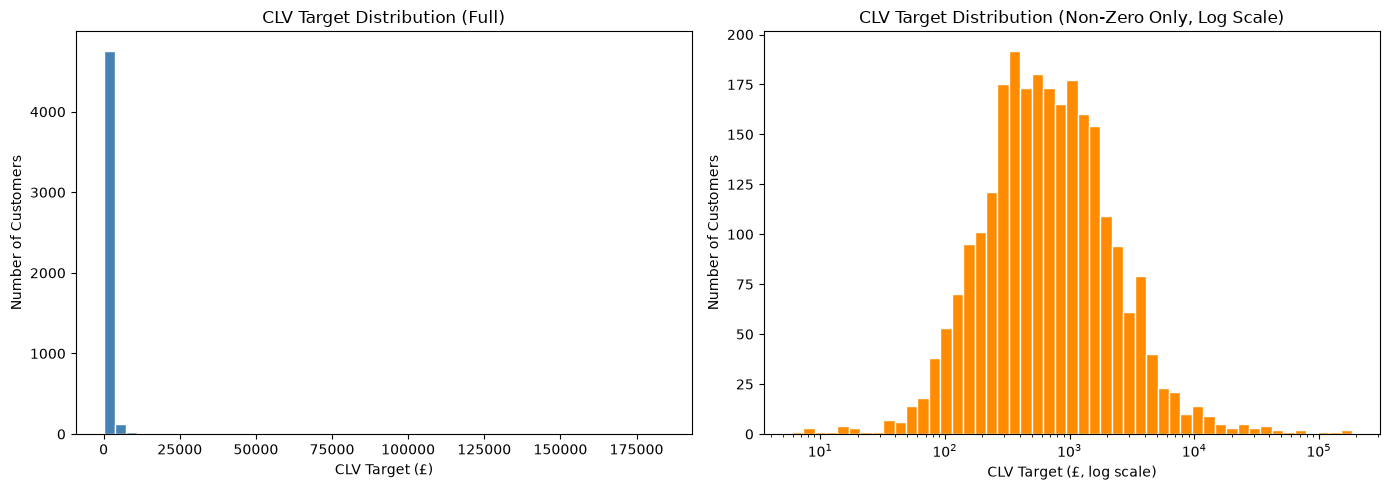

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution, including zeros
axes[0].hist(modeling_df['CLV_Target'], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("CLV Target Distribution (Full)")
axes[0].set_xlabel("CLV Target (£)")
axes[0].set_ylabel("Number of Customers")

# Distribution excluding zeros, log-scale x-axis, to see the shape among returning customers
non_zero_targets = modeling_df[modeling_df['CLV_Target'] > 0]['CLV_Target']
axes[1].hist(non_zero_targets, bins=np.logspace(np.log10(non_zero_targets.min()), np.log10(non_zero_targets.max()), 50),
             color="darkorange", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("CLV Target Distribution (Non-Zero Only, Log Scale)")
axes[1].set_xlabel("CLV Target (£, log scale)")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### CLV Target Distribution Summary

- The CLV Target distribution confirms a **zero-inflated, heavy-tailed pattern**.
- A large spike sits at exactly zero — customers with no holdout-period purchases.
- The remaining non-zero values follow a **roughly log-normal shape** (visible when plotted on a log scale), centered around £500–£1,000.
- This shape is a **known challenge for standard regression models**, which can struggle when a large portion of the target is exactly zero.
- Two approaches are worth considering in the modeling phase:
  - **Two-stage model** — first predict whether a customer will spend anything at all, then predict the amount conditional on spending.
  - **Log-transform the target** (e.g., `log(CLV_Target + 1)`) to reduce skew — a partial mitigation, but doesn't address the zero-inflation directly.
- This finding **directly informs model selection and evaluation strategy** for the Regression phase.

### Outlier Check on Engineered Features

We inspect the most extreme values in the newly engineered features (`AOV`, `Unique_Products`, `Avg_Days_Between_Purchases`) to confirm they represent genuine customer behavior rather than data anomalies, following the same approach used earlier for `Quantity` and `Price` outliers in the EDA phase.

In [18]:
# Top 10 customers by Average Order Value
modeling_df.nlargest(10, 'AOV')[['Recency', 'Frequency', 'Monetary', 'AOV']]

,Recency,Frequency,Monetary,AOV
Customer ID,,,,
15749.0,52,3,44534.30,14844.766667
13687.0,255,1,11880.84,11880.840000
12357.0,205,1,11229.99,11229.990000
18052.0,381,1,10877.18,10877.180000
12590.0,28,1,9341.26,9341.260000
12415.0,20,10,70002.74,7000.274000
13902.0,449,5,34023.26,6804.652000
12346.0,142,12,77556.46,6463.038333
17450.0,9,19,106153.72,5587.037895


In [19]:
# Top 10 customers by number of unique products purchased
modeling_df.nlargest(10, 'Unique_Products')[['Frequency', 'Monetary', 'Unique_Products']]

,Frequency,Monetary,Unique_Products
Customer ID,,,
14911.0,240,174165.35,2001
17841.0,136,40279.78,1783
12748.0,207,27303.46,1666
14156.0,115,231749.44,1228
14606.0,142,24645.78,1178
14298.0,68,70161.18,1092
13694.0,119,158800.42,776
14505.0,16,9173.51,736
14646.0,100,363191.42,728


In [20]:
# Top 10 customers by average days between purchases (least frequent buyers)
modeling_df.nlargest(10, 'Avg_Days_Between_Purchases')[['Recency', 'Frequency', 'Tenure', 'Avg_Days_Between_Purchases']]

,Recency,Frequency,Tenure,Avg_Days_Between_Purchases
Customer ID,,,,
14654.0,555,1,555,555.0
17056.0,555,1,555,555.0
17592.0,555,1,555,555.0
14106.0,554,1,554,554.0
14799.0,554,1,554,554.0
14980.0,554,1,554,554.0
15833.0,554,1,554,554.0
17087.0,554,1,554,554.0
17606.0,554,1,554,554.0


### Outlier Check Summary

- **AOV outliers** are dominated by single-order customers (`Frequency = 1`) with high `Monetary` values — mathematically expected (AOV = Monetary / Frequency) and behaviorally plausible as large one-off purchases.
- **Unique_Products outliers** are dominated by high-frequency, high-monetary customers — consistent with the large-scale wholesaler pattern identified throughout the EDA phase (e.g., a customer with 240 orders, £174,165 in spend, and 2,001 unique products purchased).
- **Avg_Days_Between_Purchases outliers** confirm our earlier reasoning exactly: every top row has `Frequency = 1`, and the feature value exactly equals `Tenure` in each case, since a single-order customer's "average gap" is mathematically just their full tenure.
- **No anomalies found** — all extreme values represent genuine customer behavior, not data errors. No further corrections are needed before saving the modeling table.

In [21]:
modeling_df.to_csv(MODELING_DATA_PATH)

## Summary

This notebook builds the modeling-ready dataset for CLV prediction, addressing a key limitation of the RFM table built in `2_eda.ipynb`: that table summarized each customer's entire history, which isn't a genuine predictive setup. Here, we split the timeline into a calibration period (used to compute features) and a holdout period (used to compute the actual future spend we're predicting), producing a real forward-looking target.

**Key steps and findings:**

- **Calibration/Holdout Split:** 18-month calibration (2009-12-01 to 2011-06-08) / 6-month holdout (2011-06-09 to 2011-12-09), chosen so the holdout period fully captures the October–November seasonal peak identified during EDA.
- **Cold-Start Exclusion:** 910 customers appeared only in the holdout period (no calibration history) and were excluded, since they have no features to predict from.
- **Returning vs. Inactive:** Of 4,951 calibration customers, 2,577 (52%) returned during holdout, while 2,374 (48%) made no holdout purchases — directly relevant to the later churn classification phase.
- **RFM Features:** Computed strictly from calibration-period data (no leakage from the future).
- **CLV Target:** Actual total revenue per customer during the holdout period, with non-returning customers correctly assigned a target of 0.
- **Additional Features:** Added Average Order Value (AOV), Tenure, Unique Products Purchased, and Average Days Between Purchases, expanding the feature set from 3 to 7 predictors.
- **Multicollinearity Check:** Correlation analysis showed some expected pairwise relationships (notably Recency ↔ Avg_Days_Between_Purchases at 0.86), but VIF analysis confirmed no severe multicollinearity (all VIF < 4) — no features were dropped.
- **Data Leakage Verification:** Explicit assertions confirmed no temporal overlap between calibration and holdout periods, and that all modeling table customers have valid calibration-period history.
- **Target Distribution:** CLV_Target is zero-inflated (48% zeros) and heavy-tailed/log-normal among non-zero values — an important finding that will directly inform model selection (e.g., a two-stage model or log-transformation) in the Regression phase.
- **Outlier Verification:** Extreme values in all engineered features were traced to genuine customer behavior (large one-off purchases, wholesale buyers, single-order customers), not data errors.

**Output:** A fully validated modeling table (`modeling_table.csv`) containing 4,951 customers with 7 features (Recency, Frequency, Monetary, AOV, Tenure, Unique_Products, Avg_Days_Between_Purchases) and a CLV_Target column, ready for the Regression phase.